In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from math import sqrt
import ROOT
import ctypes
try:
#     plt.style.use('belle2')
    plt.style.use('belle2_serif')
#     plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style") 
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

from matplotlib.ticker import ScalarFormatter


Welcome to JupyROOT 6.26/04


In [2]:
from math import sqrt

# Error-weighted combination function
def combine_error_weighted(x, y, x_err, y_err):
    central_value = (x / x_err**2 + y / y_err**2) / (1 / x_err**2 + 1 / y_err**2)
    error = 1 / sqrt(1 / x_err**2 + 1 / y_err**2)
    return central_value, error

In [3]:
# # signal_eff_error = math.sqrt(signal_eff * (1 - signal_eff) / N_gen)

# def calculate_sig_eff_err(eff, N_gen):

#     error = math.sqrt(eff * (1 - eff) / N_gen)
#     return error

In [4]:
def correct_Acp_stats( Araw, Araw_err, Aref, Aref_err, Aref_pdg, Aref_K_mix):
    final_Acp = Araw - Aref + Aref_pdg + Aref_K_mix
    final_Acp_err = sqrt(Araw_err**2 + Aref_err**2)

    return final_Acp, final_Acp_err

In [5]:
def correct_Acp_stats_etaKp( Araw, Araw_err, \
                            Aref_Ds_KsKp, Aref_Ds_KsKp_err, Aref_Ds_KsKp_pdg, \
                            Aref_Ds_PhiPip, Aref_Ds_PhiPip_err, Aref_Ds_PhiPip_pdg, \
                            Aref_Dp_KsPip, Aref_Dp_KsPip_err, Aref_Dp_KsPip_pdg, \
                            A_K_mix):
    final_Acp = Araw + (- Aref_Ds_KsKp + Aref_Ds_KsKp_pdg + A_K_mix) + ( + Aref_Ds_PhiPip - Aref_Ds_PhiPip_pdg ) + (- Aref_Dp_KsPip + Aref_Dp_KsPip_pdg + A_K_mix)
    final_Acp_err = sqrt(Araw_err**2 + Aref_Ds_KsKp_err**2 + Aref_Ds_PhiPip_err**2 + Aref_Dp_KsPip_err**2)

    return final_Acp, final_Acp_err

# MC15 full

## Acp(D+ -> eta K+)

### eta -> gg corrected by D+ -> Ks K+ (SCS)

In [33]:
Araw_gg =  0.01583545315174241
Araw_gg_stats_error = 0.08062806818614812

In [34]:
Aref_gg = 0.00527281845539265
Aref_gg_stats_error = 0.007949456011155265

Aref_gg_pdg = -0.0001
Aref_gg_pdg_sys_error = 0.0007

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [35]:
Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg, Aref_K_mix)

In [36]:
Acp_etapip_gg_value

0.009762634696349762

In [37]:
Acp_etapip_gg_error

0.08101900536481205

### eta -> pipipi corrected by D+ -> Ks K+ (SCS)

In [38]:
Araw_pipipi =   0.01847105903700951
Araw_pipipi_stats_error = 0.0919838602304539

In [39]:
Aref_pipipi = 0.0056168970313861906 
Aref_pipipi_stats_error = 0.00626478370590158

Aref_pipipi_pdg = -0.0001
Aref_pipipi_pdg_sys_error = 0.0007

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [40]:
Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg, Aref_K_mix)

In [41]:
Acp_etapip_pipipi_value

0.012054162005623321

In [42]:
Acp_etapip_pipipi_error

0.0921969525406204

In [43]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

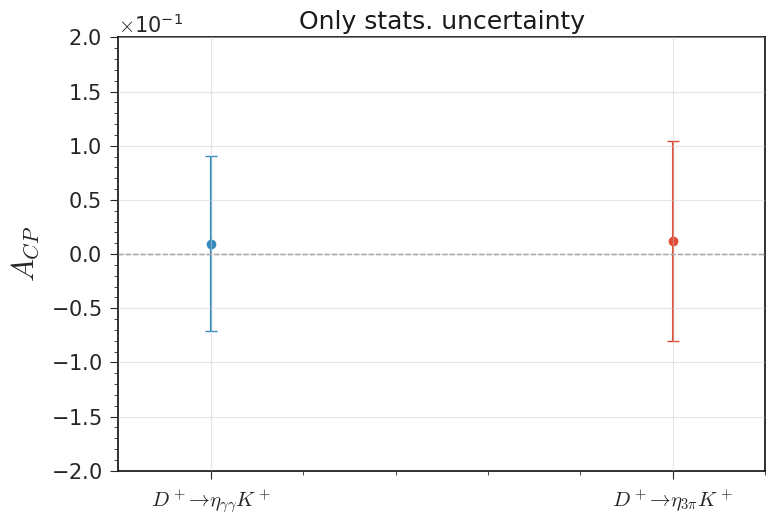

In [46]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D^+ \to \eta_{\gamma\gamma} K^+$', r'$D^+ \to \eta_{3\pi} K^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D^+ \to \eta_{\gamma\gamma} K^+$', r'$D^+ \to \eta_{3\pi} K^+$'])

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-2*0.1 , 2*0.1)
plt.tight_layout()
plt.savefig("MC15rd_427_87_etaKp_Acp_v7_fitv1_corr_Kshp.png")
plt.show()

In [47]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [48]:
combined_central_value

0.010761135098911044

In [49]:
combined_error

0.060859470526036366

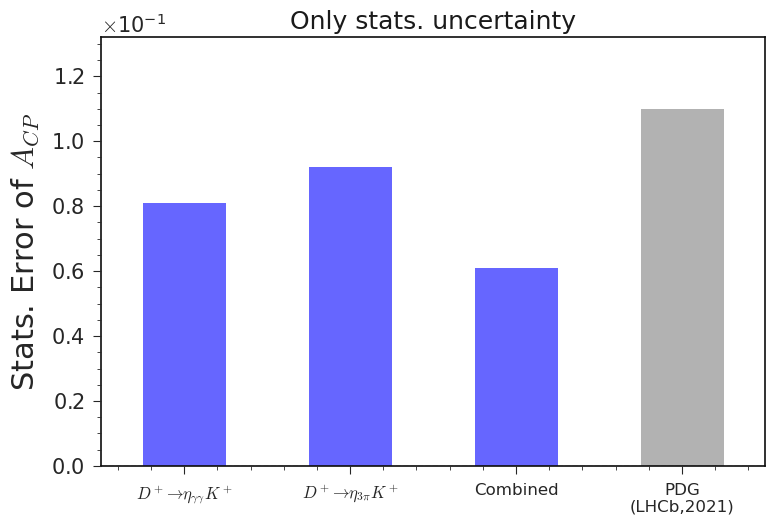

In [50]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.11]

colors = ['blue', 'blue', 'blue', 'gray']
# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4], errors, color=colors, alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4], [r'$D^+ \to \eta_{\gamma\gamma} K^+$', r'$D^+ \to \eta_{3\pi} K^+$', 'Combined','PDG\n(LHCb,2021)'], fontsize=12)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()

# Save and display
plt.savefig("MC15rd_427_87_etaKp_Acp_error_bars_v7_fitv1_corr_Kshp.png")
plt.show()


### eta -> gg corrected by all 3 CF decays

In [49]:
Araw_gg =  0.01583545315174241
Araw_gg_stats_error = 0.08062806818614812

In [50]:
Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

Aref_Ds_KsKp = 0.00527281845539265
Aref_Ds_KsKp_stats_error = 0.007949456011155265

Aref_Ds_KsKp_pdg = -0.0001
Aref_Ds_KsKp_pdg_sys_error = 0.0007

Aref_Ds_PhiPip = 0.0024951940796039147
Aref_Ds_PhiPip_stats_error =  0.0034900976398089217

Aref_Ds_PhiPip_pdg = -0.0038
Aref_Ds_PhiPip_pdg_sys_error = 0.0027

Aref_Dp_KsPip =  -0.0012501200333421495
Aref_Dp_KsPip_stats_error = 0.002606070899780176

Aref_Dp_KsPip_pdg = -0.0041
Aref_Dp_KsPip_sys_error = 0.0009

In [51]:
Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats_etaKp(Araw_gg, Araw_gg_stats_error, \
                                                                  Aref_Ds_KsKp, Aref_Ds_KsKp_stats_error, Aref_Ds_KsKp_pdg, \
                                                                  Aref_Ds_PhiPip, Aref_Ds_PhiPip_stats_error, Aref_Ds_PhiPip_pdg, \
                                                                  Aref_Dp_KsPip, Aref_Dp_KsPip_stats_error, Aref_Dp_KsPip_pdg, \
                                                                  Aref_K_mix)

In [52]:
Acp_etapip_gg_value

0.012507948809295823

In [53]:
Acp_etapip_gg_error

0.08113600691045575

### eta -> pipipi corrected by all 3 CF decays

In [54]:
Araw_pipipi =   0.01847105903700951
Araw_pipipi_stats_error = 0.0919838602304539

In [55]:
Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

Aref_Ds_KsKp = 0.00492350938439085
Aref_Ds_KsKp_stats_error = 0.004405226292927789

Aref_Ds_KsKp_pdg = -0.0001
Aref_Ds_KsKp_pdg_sys_error = 0.0007

Aref_Ds_PhiPip = 0.0016476602084172036
Aref_Ds_PhiPip_stats_error =   0.002934847106236558

Aref_Ds_PhiPip_pdg = -0.0038
Aref_Ds_PhiPip_pdg_sys_error = 0.0027

Aref_Dp_KsPip = 0
Aref_Dp_KsPip_stats_error = 0

Aref_Dp_KsPip_pdg = -0.0041
Aref_Dp_KsPip_sys_error = 0.0009

In [56]:
Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats_etaKp(Araw_pipipi, Araw_pipipi_stats_error, \
                                                                  Aref_Ds_KsKp, Aref_Ds_KsKp_stats_error, Aref_Ds_KsKp_pdg, \
                                                                  Aref_Ds_PhiPip, Aref_Ds_PhiPip_stats_error, Aref_Ds_PhiPip_pdg, \
                                                                  Aref_Dp_KsPip, Aref_Dp_KsPip_stats_error, Aref_Dp_KsPip_pdg, \
                                                                  Aref_K_mix)

In [57]:
Acp_etapip_pipipi_value

0.013395209861035864

In [58]:
Acp_etapip_pipipi_error

0.0921360401207072

In [59]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

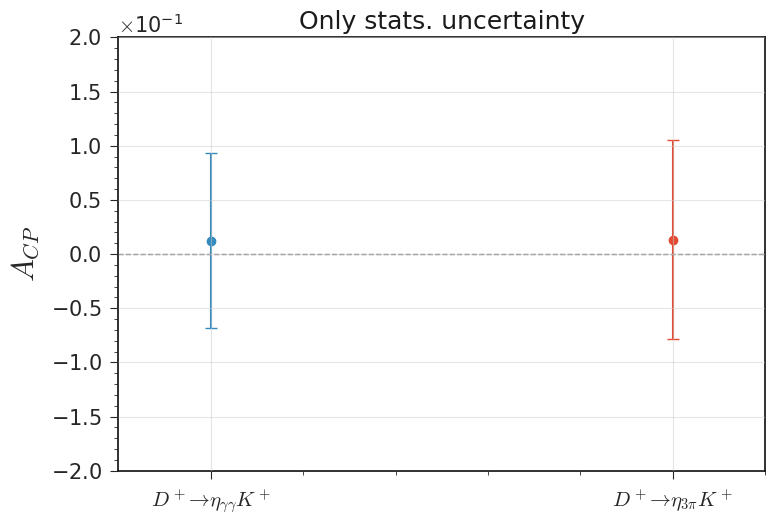

In [60]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D^+ \to \eta_{\gamma\gamma} K^+$', r'$D^+ \to \eta_{3\pi} K^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D^+ \to \eta_{\gamma\gamma} K^+$', r'$D^+ \to \eta_{3\pi} K^+$'])

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-2*0.1 , 2*0.1)
plt.tight_layout()
plt.savefig("MC15rd_427_87_etaKp_Acp_v7_fitv1_corr_DsKsK_DsPhiPi_DpKsPi.png")
plt.show()

In [61]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [62]:
combined_central_value

0.012895478398263332

In [63]:
combined_error

0.06089144327071248

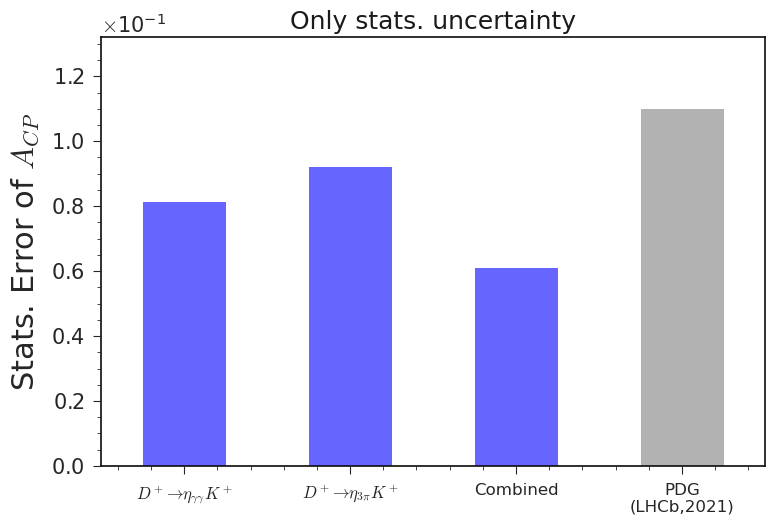

In [64]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.11]

colors = ['blue', 'blue', 'blue', 'gray']
# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4], errors, color=colors, alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4], [r'$D^+ \to \eta_{\gamma\gamma} K^+$', r'$D^+ \to \eta_{3\pi} K^+$', 'Combined','PDG\n(LHCb,2021)'], fontsize=12)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()

# Save and display
plt.savefig("MC15rd_427_87_etaKp_Acp_error_bars_v7_fitv1_corr_DsKsK_DsPhiPi_DpKsPi.png")
plt.show()


## Acp(Ds+ -> eta K+)

### eta -> gg

In [5]:
Araw_gg =   0.020318436885201237
Araw_gg_stats_error = 0.02740547890105216

In [6]:
Aref_gg = 0.00245641462626375 
Aref_gg_stats_error = 0.00554491851809791

Aref_gg_pdg = 0.0009
Aref_gg_pdg_sys_error = 0.0026

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [7]:
Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg, Aref_K_mix)

In [8]:
Acp_etapip_gg_value

0.01806202225893749

In [9]:
Acp_etapip_gg_error

0.027960801046614532

### eta -> pipipi

In [10]:
Araw_pipipi =    0.0006855060377437235
Araw_pipipi_stats_error = 0.03546320797890886

In [11]:
Aref_pipipi = 0.004930697886038386 
Aref_pipipi_stats_error = 0.0023174827746715826

Aref_pipipi_pdg = 0.0009
Aref_pipipi_pdg_sys_error = 0.0026

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [12]:
Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg, Aref_K_mix)

In [13]:
Acp_etapip_pipipi_value

-0.004045191848294663

In [14]:
Acp_etapip_pipipi_error

0.035538849820530835

In [15]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

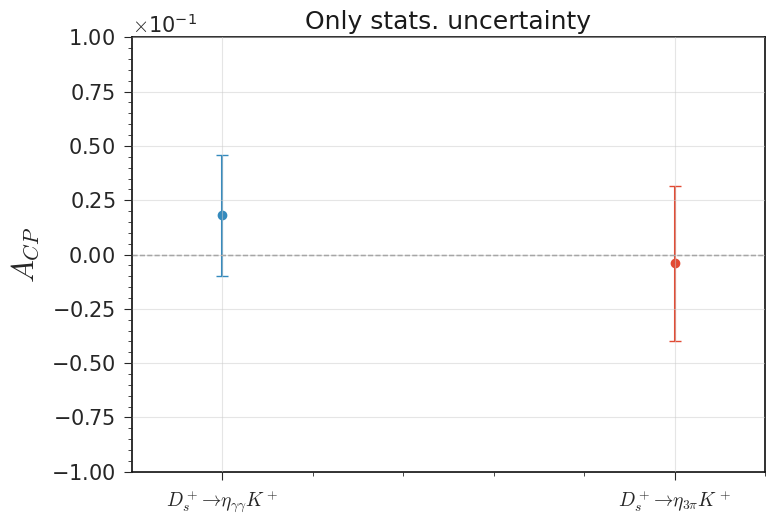

In [20]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D_s^+ \to \eta_{\gamma\gamma} K^+$', r'$D_s^+ \to \eta_{3\pi} K^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D_s^+ \to \eta_{\gamma\gamma} K^+$', r'$D_s^+ \to \eta_{3\pi} K^+$'], fontsize=14)

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-10*0.01 , 10*0.01)

plt.tight_layout()
plt.savefig("MC15rd_427_87_etaKp_Acp_v7_fitv1_corr_Kshp_Ds.png")
plt.show()

In [21]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [22]:
combined_central_value

0.009609643499597849

In [23]:
combined_error

0.021974845710062363

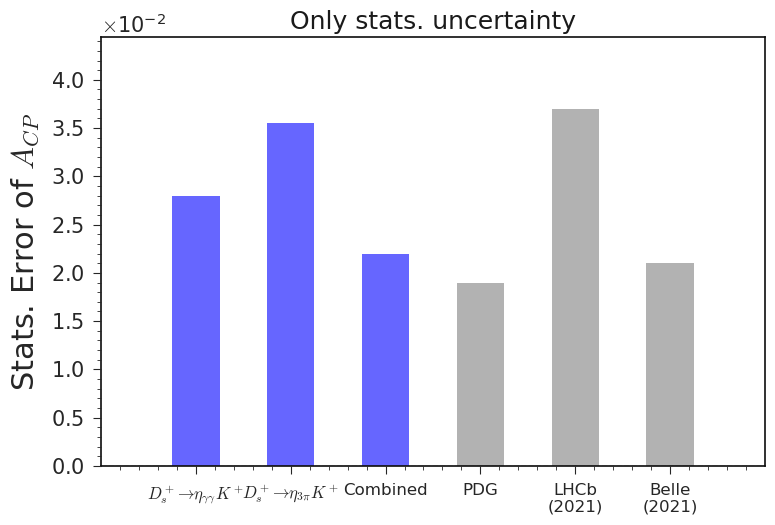

In [24]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.019, 0.037, 0.021]

colors = ['blue', 'blue', 'blue', 'gray', 'gray', 'gray', 'gray']

# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4, 5, 6], errors, color=colors, alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6], [r'$D_s^+ \to \eta_{\gamma\gamma} K^+$', r'$D_s^+ \to \eta_{3\pi} K^+$', 'Combined','PDG','LHCb\n(2021)','Belle\n(2021)'], fontsize=12)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()

# Save and display
plt.savefig("MC15rd_427_87_etaKp_Acp_error_bars_v7_fitv1_corr_Kshp_Ds.png")
plt.show()
